In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.model_selection import cross_val_score
import joblib

sns.set_style("whitegrid")

In [ ]:
# Re-load the dataset to ensure a clean state
df = pd.read_csv('Telco-Customer-Churn.csv')

In [ ]:
print("Head of Data")
print(df.head())

Head of Data
  customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0      C0001    Male              0      No        Yes      56          Yes   
1      C0002  Female              0      No        Yes      71          Yes   
2      C0003    Male              0      No         No       6          Yes   
3      C0004    Male              0      No        Yes      55          Yes   
4      C0005    Male              0     Yes        Yes      66          Yes   

  MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0           Yes             DSL            Yes  ...               No   
1            No             DSL            Yes  ...               No   
2            No             DSL            Yes  ...              Yes   
3            No             DSL            Yes  ...              Yes   
4           Yes     Fiber optic            Yes  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract PaperlessBilling  \
0

In [ ]:
print("Dataset Information")
print(df.info())

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        1000 non-null   object 
 1   gender            1000 non-null   object 
 2   SeniorCitizen     1000 non-null   int64  
 3   Partner           1000 non-null   object 
 4   Dependents        1000 non-null   object 
 5   tenure            1000 non-null   int64  
 6   PhoneService      1000 non-null   object 
 7   MultipleLines     1000 non-null   object 
 8   InternetService   1000 non-null   object 
 9   OnlineSecurity    1000 non-null   object 
 10  OnlineBackup      1000 non-null   object 
 11  DeviceProtection  1000 non-null   object 
 12  TechSupport       1000 non-null   object 
 13  StreamingTV       1000 non-null   object 
 14  StreamingMovies   1000 non-null   object 
 15  Contract          1000 non-null   object 
 16  PaperlessBilling  1000 

In [ ]:
print("Shape of Dataset:", df.shape)

Shape of Dataset: (1000, 21)


In [ ]:
print("Column Names")
print(df.columns)

Column Names
Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')


In [ ]:
print("Statistical Summary")
print(df.describe())

Statistical Summary
       SeniorCitizen      tenure  MonthlyCharges  TotalCharges
count    1000.000000  1000.00000     1000.000000   1000.000000
mean        0.168000    36.39100       68.033220   2470.150690
std         0.374053    20.63686       28.634748   1841.160052
min         0.000000     0.00000       18.010000      0.000000
25%         0.000000    19.00000       43.167500   1001.340000
50%         0.000000    37.00000       69.085000   2073.795000
75%         0.000000    55.00000       91.877500   3628.705000
max         1.000000    71.00000      117.900000   8032.040000


In [ ]:
print("Missing Values in Dataset")
print(df.isnull().sum())

Missing Values in Dataset
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        1000 non-null   object 
 1   gender            1000 non-null   object 
 2   SeniorCitizen     1000 non-null   int64  
 3   Partner           1000 non-null   object 
 4   Dependents        1000 non-null   object 
 5   tenure            1000 non-null   int64  
 6   PhoneService      1000 non-null   object 
 7   MultipleLines     1000 non-null   object 
 8   InternetService   1000 non-null   object 
 9   OnlineSecurity    1000 non-null   object 
 10  OnlineBackup      1000 non-null   object 
 11  DeviceProtection  1000 non-null   object 
 12  TechSupport       1000 non-null   object 
 13  StreamingTV       1000 non-null   object 
 14  StreamingMovies   1000 non-null   object 
 15  Contract          1000 non-null   object 
 16  PaperlessBilling  1000 non-null   object 
 

In [ ]:
df.drop('customerID', axis=1, inplace=True)

In [ ]:
print("Churn Distribution")
print(df['Churn'].value_counts())

Churn Distribution
Churn
No     767
Yes    233
Name: count, dtype: int64


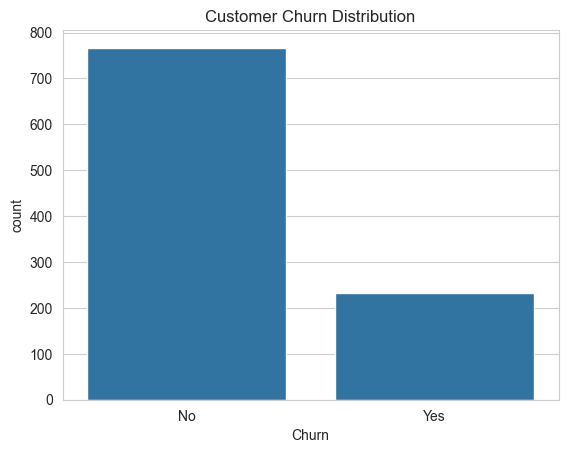

In [ ]:
sns.countplot(x='Churn', data=df)
plt.title("Customer Churn Distribution")
plt.show()

In [ ]:
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']
df[numerical_cols].describe()

,tenure,MonthlyCharges,TotalCharges,SeniorCitizen
count,1000.00000,1000.000000,1000.000000,1000.000000
mean,36.39100,68.033220,2470.150690,0.168000
std,20.63686,28.634748,1841.160052,0.374053
min,0.00000,18.010000,0.000000,0.000000
25%,19.00000,43.167500,1001.340000,0.000000
50%,37.00000,69.085000,2073.795000,0.000000
75%,55.00000,91.877500,3628.705000,0.000000
max,71.00000,117.900000,8032.040000,1.000000


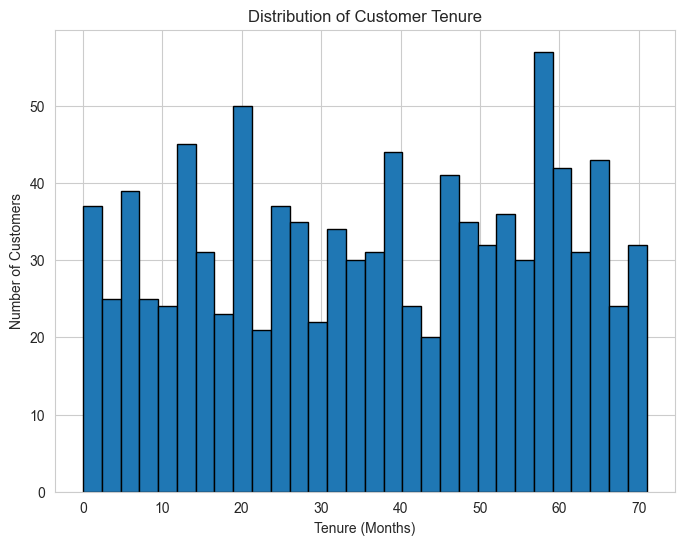

In [ ]:
plt.figure(figsize=(8,6))
plt.hist(df['tenure'], bins=30, edgecolor='black')
plt.title('Distribution of Customer Tenure')
plt.xlabel('Tenure (Months)')
plt.ylabel('Number of Customers')
plt.show()

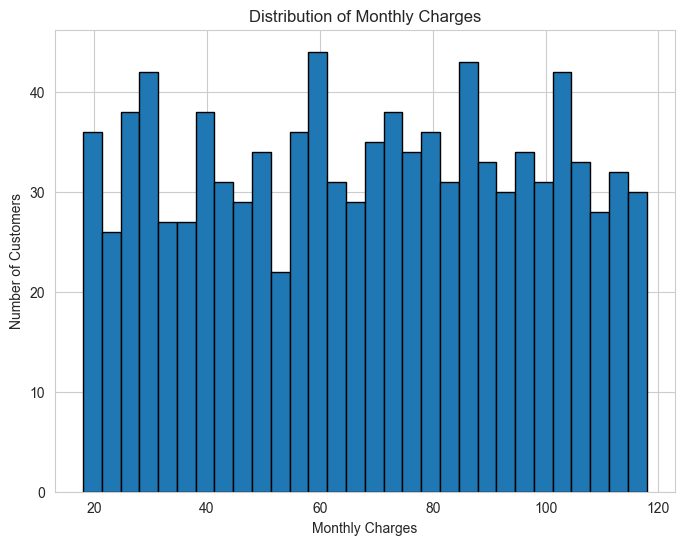

In [ ]:
plt.figure(figsize=(8,6))
plt.hist(df['MonthlyCharges'], bins=30, edgecolor='black')
plt.title('Distribution of Monthly Charges')
plt.xlabel('Monthly Charges')
plt.ylabel('Number of Customers')
plt.show()

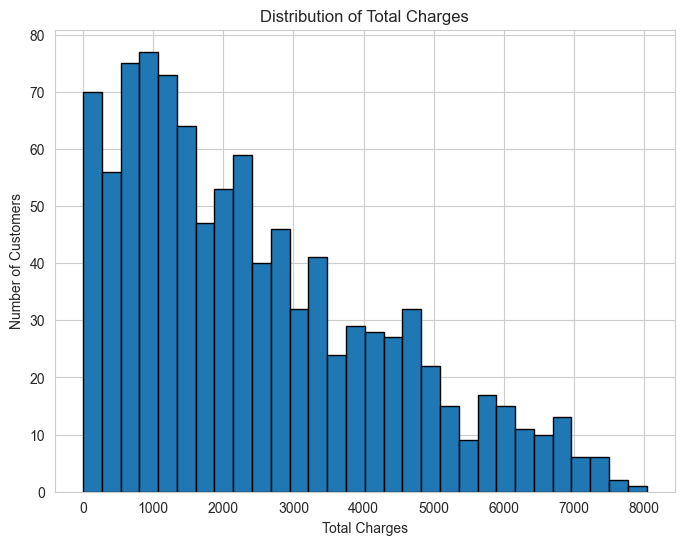

In [ ]:
plt.figure(figsize=(8,6))
plt.hist(df['TotalCharges'], bins=30, edgecolor='black')
plt.title('Distribution of Total Charges')
plt.xlabel('Total Charges')
plt.ylabel('Number of Customers')
plt.show()

In [ ]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()
print("Categorical Columns:", categorical_cols)

Categorical Columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


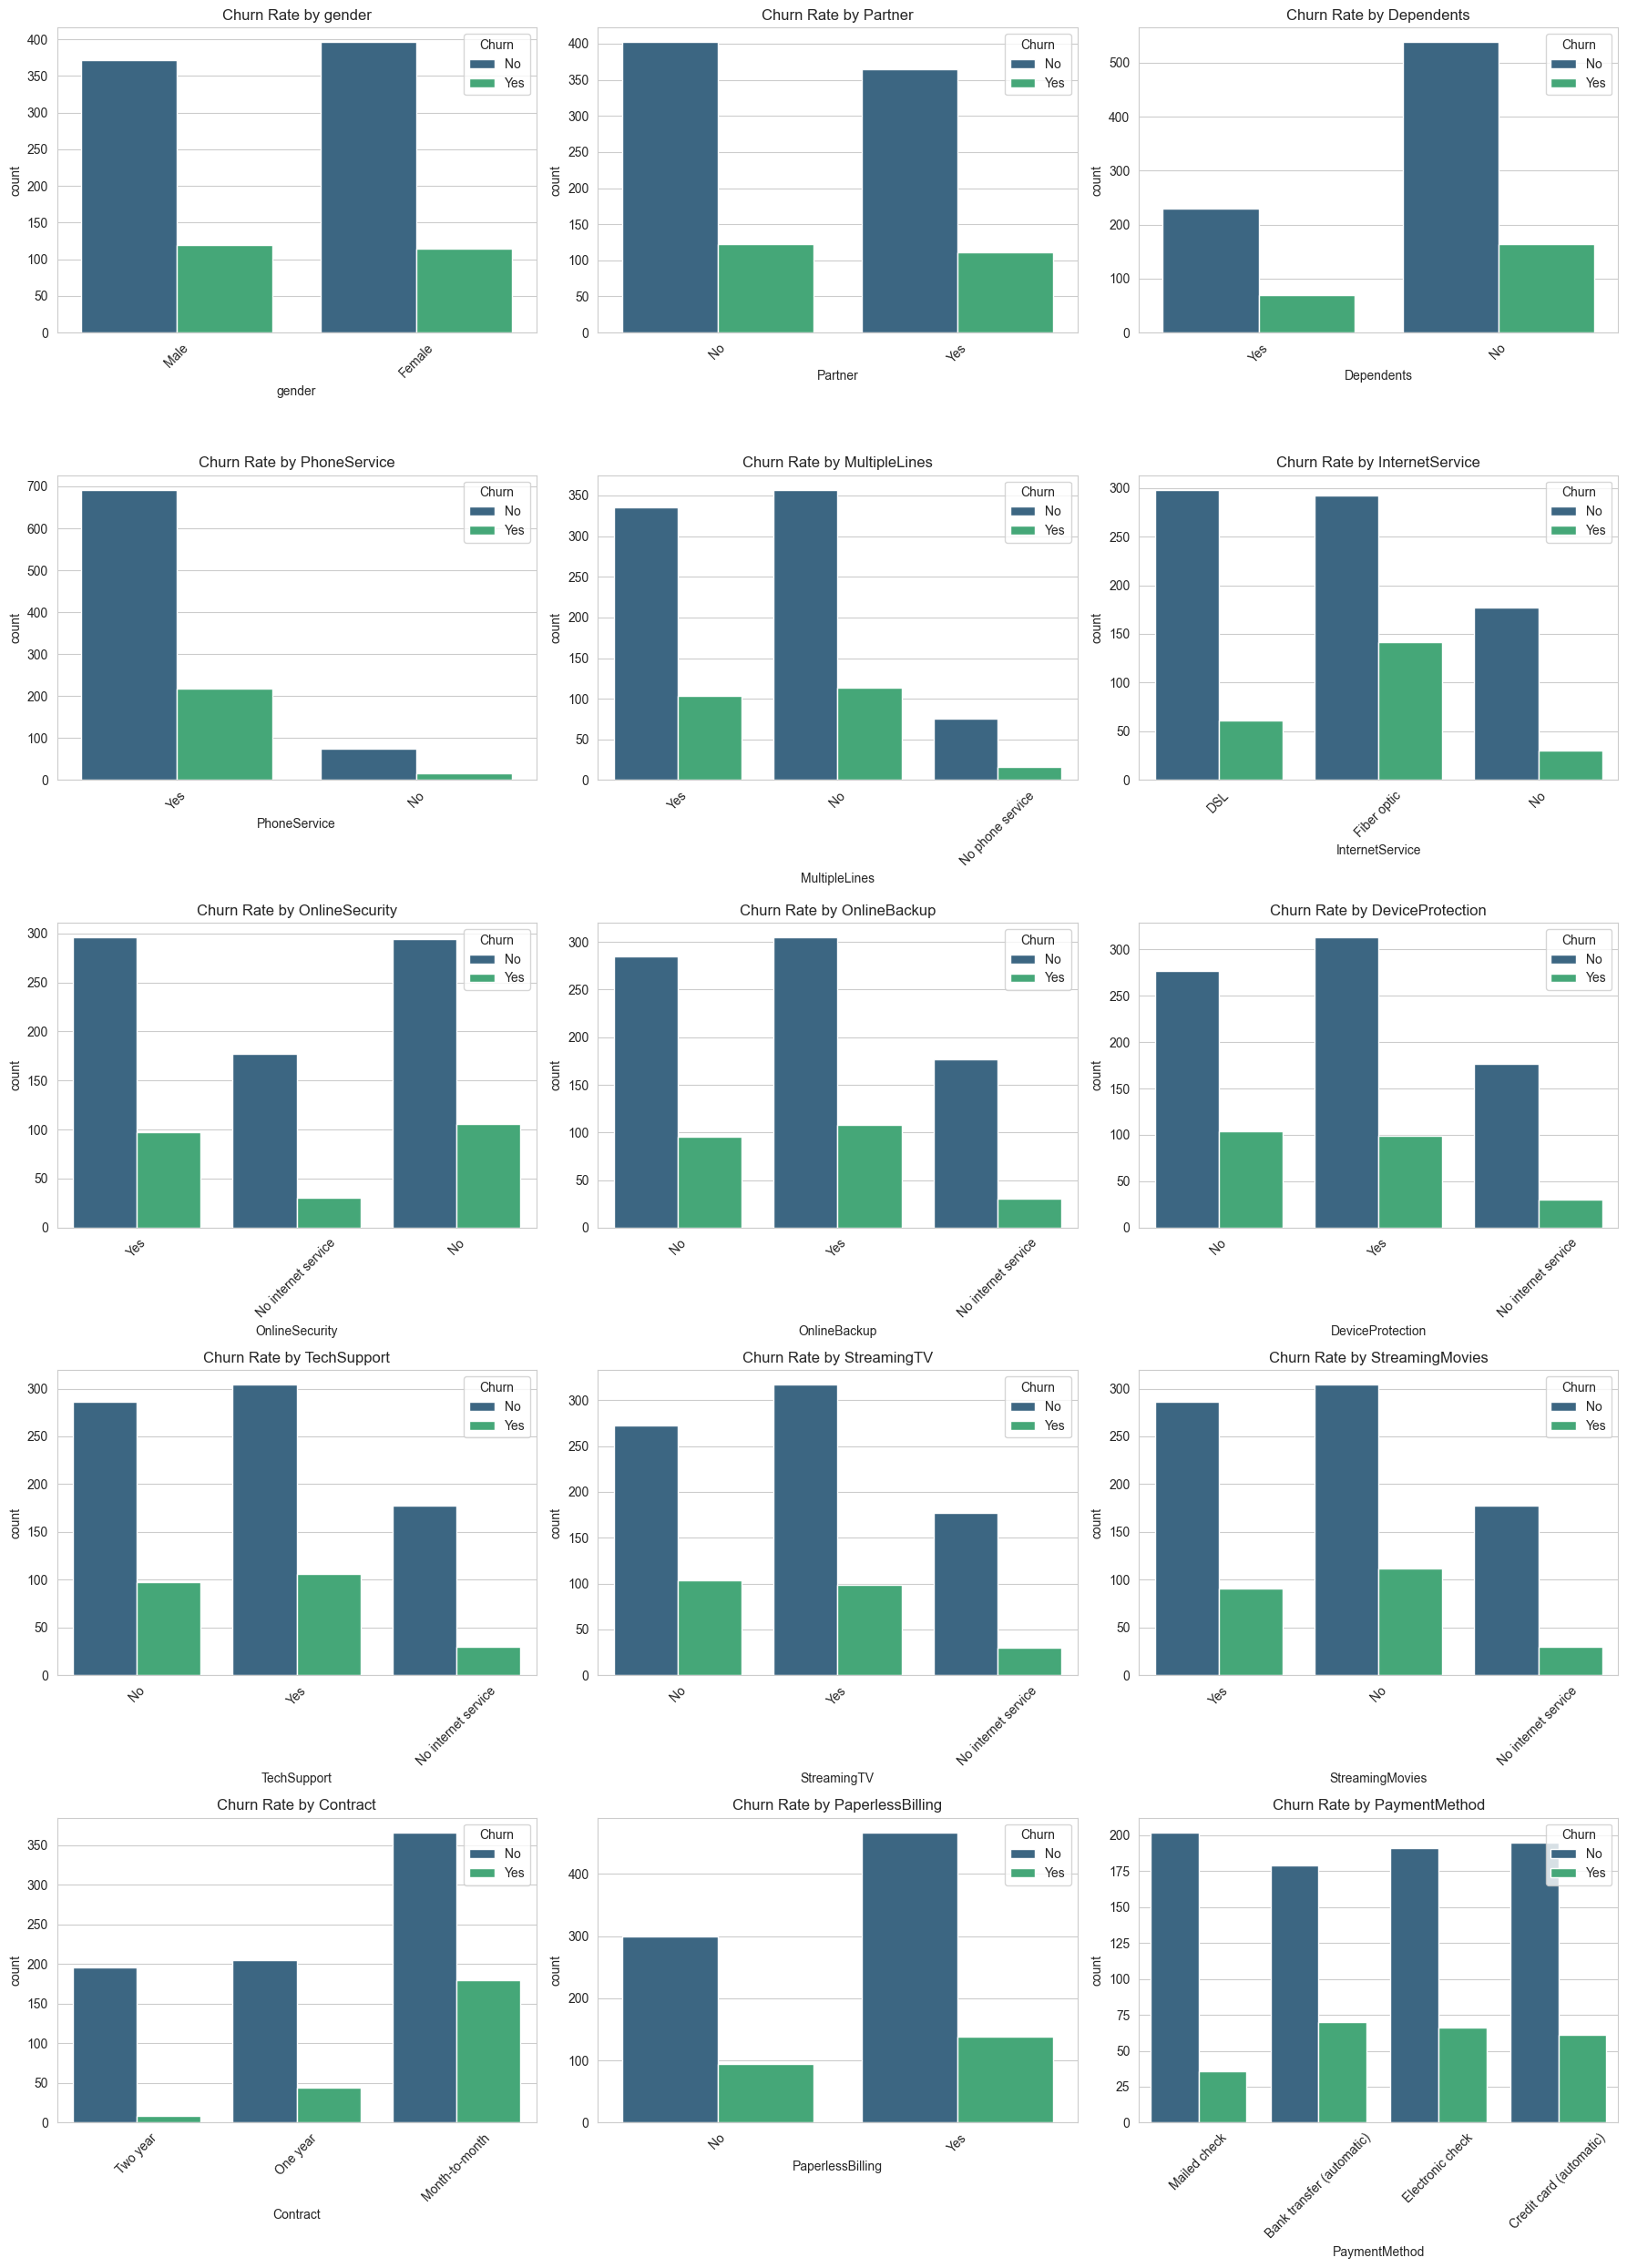

In [ ]:
churn_related_categorical_cols = [col for col in categorical_cols if col != 'Churn']

num_cols = len(churn_related_categorical_cols)
num_rows = (num_cols + 2) // 3

plt.figure(figsize=(18, 5 * num_rows))

for i, col in enumerate(churn_related_categorical_cols):
    plt.subplot(num_rows, 3, i + 1)
    sns.countplot(data=df, x=col, hue='Churn', palette='viridis')
    plt.title(f'Churn Rate by {col}')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

C:\Users\Durvashri Dabke\AppData\Local\Temp\ipykernel_47704\2605657621.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='tenure', palette='viridis')


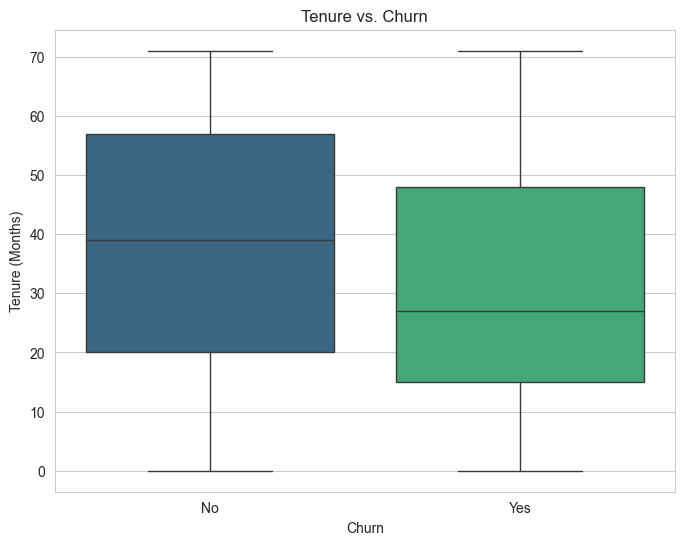

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='Churn', y='tenure', palette='viridis')
plt.title('Tenure vs. Churn')
plt.xlabel('Churn')
plt.ylabel('Tenure (Months)')
plt.show()

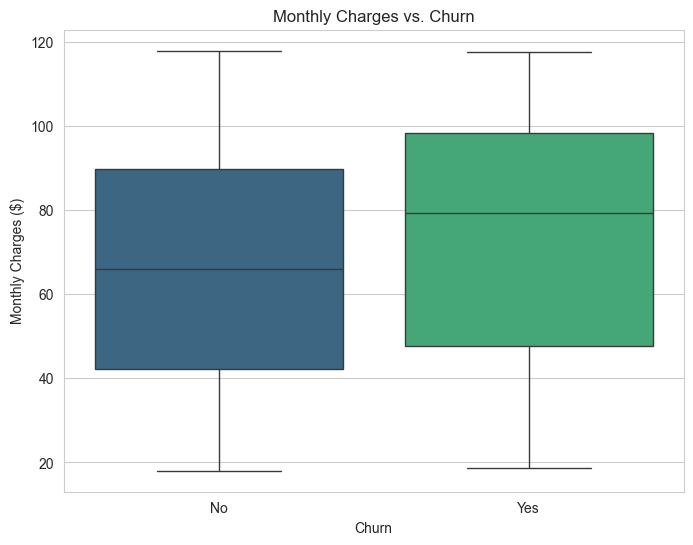

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', hue='Churn', palette='viridis', legend=False)
plt.title('Monthly Charges vs. Churn')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges ($)')
plt.show()

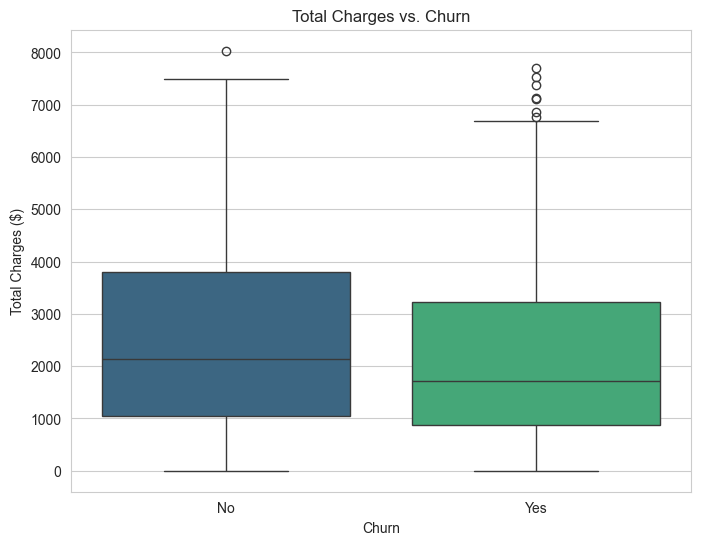

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='Churn', y='TotalCharges', hue='Churn', palette='viridis', legend=False)
plt.title('Total Charges vs. Churn')
plt.xlabel('Churn')
plt.ylabel('Total Charges ($)')
plt.show()

In [ ]:
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

In [ ]:
for col in numerical_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Capping outliers
    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])

C:\Users\Durvashri Dabke\AppData\Local\Temp\ipykernel_47704\505411380.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=df[col], palette='viridis')


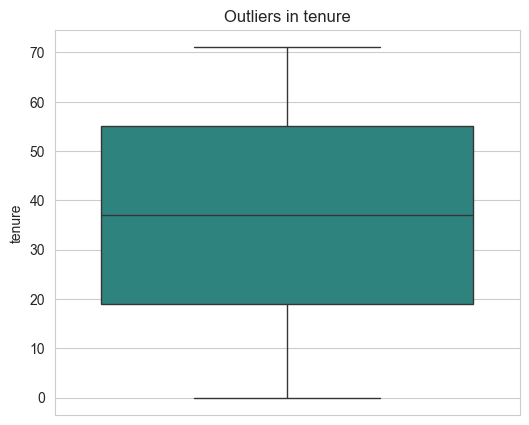

C:\Users\Durvashri Dabke\AppData\Local\Temp\ipykernel_47704\505411380.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=df[col], palette='viridis')


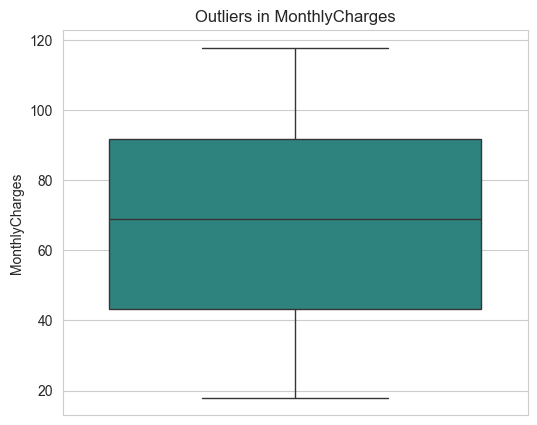

C:\Users\Durvashri Dabke\AppData\Local\Temp\ipykernel_47704\505411380.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=df[col], palette='viridis')


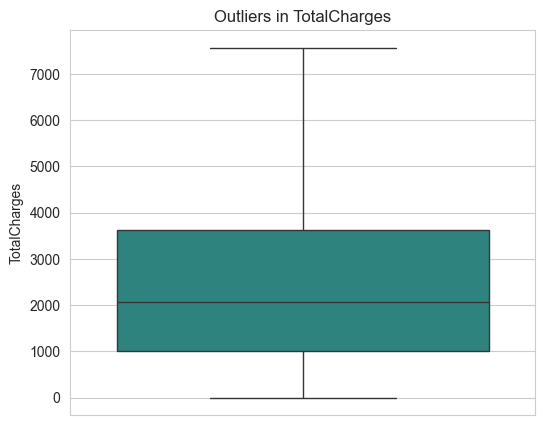

In [ ]:
numerical_cols = ['tenure','MonthlyCharges','TotalCharges']

for col in numerical_cols:
    plt.figure(figsize=(6,5))
    sns.boxplot(y=df[col], palette='viridis')
    plt.title(f'Outliers in {col}')
    plt.ylabel(col)
    plt.show()

In [ ]:
df['Churn'] = df['Churn'].map({'Yes':1,'No':0})

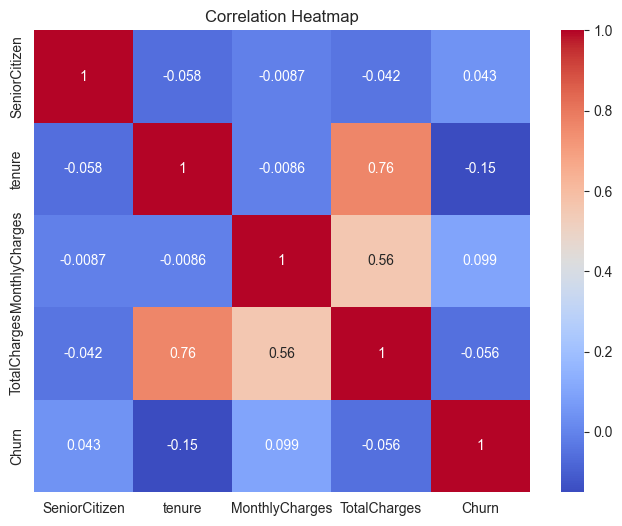

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

EDA Finished

In [ ]:
yes_no_cols = ['Partner','Dependents','PhoneService','PaperlessBilling']

for col in yes_no_cols:
    df[col] = df[col].map({'Yes':1,'No':0})

In [ ]:
df = pd.get_dummies(df, drop_first=True)

In [ ]:
X = df.drop('Churn', axis=1)
y = df['Churn']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))

Logistic Regression Accuracy: 0.745


In [ ]:
from sklearn.tree import DecisionTreeClassifier # Import DecisionTreeClassifier

dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 0.675


In [ ]:
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.73


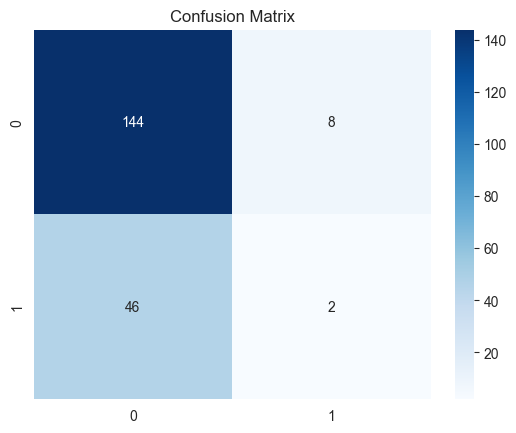

In [ ]:
cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

In [ ]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.76      0.95      0.84       152
           1       0.20      0.04      0.07        48

    accuracy                           0.73       200
   macro avg       0.48      0.49      0.46       200
weighted avg       0.62      0.73      0.66       200



In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier()
}

for name, model in models.items():

    scores = cross_val_score(model, X, y, cv=5)

    print(name)
    print("Scores:", scores)
    print("Average Accuracy:", scores.mean())
    print("-----------------------")

d:\Data Science\EXTRA PROJECTS\telco_churn_project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
d:\Data Science\EXTRA PROJECTS\telco_churn_project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https

Logistic Regression
Scores: [0.78  0.75  0.78  0.78  0.755]
Average Accuracy: 0.7689999999999999
-----------------------
Decision Tree
Scores: [0.715 0.7   0.72  0.68  0.675]
Average Accuracy: 0.6980000000000001
-----------------------
Random Forest
Scores: [0.78  0.745 0.765 0.77  0.74 ]
Average Accuracy: 0.76
-----------------------


In [ ]:
import joblib

# Save feature column names captured BEFORE scaling (while X is still a DataFrame)
feature_cols = list(X.columns)

# Save model and scaler as dicts with feature_cols embedded
joblib.dump({'model': rf_model, 'feature_cols': feature_cols}, 'churn_model.pkl')
joblib.dump({'scaler': scaler,  'feature_cols': feature_cols}, 'scaler.pkl')

print('Saved churn_model.pkl and scaler.pkl with feature columns')


Saved churn_model.pkl and scaler.pkl with feature columns


In [ ]:
# Quick sanity check: predict on first test sample
sample = X_test[:1]
pred = rf_model.predict(sample)
prob = rf_model.predict_proba(sample)
print("Sample prediction:", "Churn" if pred[0]==1 else "No Churn")
print(f"Confidence — No Churn: {prob[0][0]:.2%}, Churn: {prob[0][1]:.2%}")


Sample prediction: No Churn
Confidence — No Churn: 81.00%, Churn: 19.00%
